<div style="background-color: #F4F6F7; padding: 20px; border-radius: 8px; font-family: 'Arial', sans-serif; color: #2E4053;">
  <!-- Logo centrado -->
  <div style="text-align: center; margin-bottom: 15px;">
    <img src="https://drive.google.com/uc?export=view&id=1kjzXfjTiieYAd4azw5bh4UfEg91gUIdh" alt="Logo Institucional" width="250" />
  </div>

  <!-- Título principal -->
  <h1 style="font-size: 36px; font-weight: bold; text-align: right;">
    <strong>Preprocesamiento de las imágenes multiespectrales del LANDSAT 7</strong>
  </h1>

  <!-- Datos del estudiante -->
  <p style="font-size: 22px; text-align: center; margin: 5px 0;">
    <strong>Nombre:</strong> Carlos Enrique Montilla Morales &nbsp;|&nbsp;
    <strong>Institución:</strong> Universidad Tecnológica de Pereira  &nbsp;|&nbsp;
    <strong>Grupo de investigación en Automática </strong>
  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />

  <!-- Descripción breve -->
  <p style="font-size: 18px; text-align: center; font-style: italic; margin: 5px 0;">
    Este cuaderno contiene el preprocesamiento completo para obtener los recortes multibanda en formato GEOTIFF de las rásters de los archivos HDF de la misión LANDSAT-7. Donde se toman las coordenadas de las bases de datos de puntos en Colombia y se recortan imágenes de 10 km de lado tomando como centro dicha coordenada. Luego se verifican si faltan archivos y si están bien para su implementación posterior. En el caso de que estén mal o falten, se realizan varias adiciones al c´doigo original para obtener las imágenes en buenas condiciones.

  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />
</div>


# **Preprocesamiento de las imágenes satelitales**

Se emplearán los rásters de la misión LANDSAT 7 del año 2010 en el mes de Junio para a partir de las coordenadas de los puntos donde se conoce el gradiente geotérmico, obtener pequeños parches de 10 km de longitud en formato Geotiff. 

In [1]:
import argparse
import glob
import math
import os
import re
import shutil
import traceback
import numpy as np
import pandas as pd

# Librerías de geoprocesamiento / GIS
from osgeo import gdal

import rasterio
from rasterio.windows import Window
from rasterio.windows import from_bounds
from rasterio.windows import transform as window_transform
from rasterio.warp import transform_bounds

from pyproj import CRS, Geod, Transformer

# Librerías para HDF
from pyhdf.SD import SD, SDC

import matplotlib.pyplot as plt


## **Conocimiento de las capas de los rásters**

In [2]:
file_path = "LANDSAT/LANDSAT7_14.hdf"

# Abrir archivo en modo lectura
hdf = SD(file_path, SDC.READ)

# Listar datasets (bandas)
datasets = hdf.datasets()

print("Bandas encontradas en el archivo:")
for name, info in datasets.items():
    dims = info[1]
    dtype = info[3]
    print(f" - {name} | Dimensiones: {dims} | Tipo de datos: {dtype}")

# Acceder a todas las bandas de interés
first_band = list(datasets.keys())[0]
first_band = hdf.select(first_band)[:]  # Leer datos como array de numpy
second_band = list(datasets.keys())[1]
second_band = hdf.select(second_band)[:]  # Leer datos como array de numpy  
third_band = list(datasets.keys())[2]
third_band = hdf.select(third_band)[:]  # Leer datos como array de numpy
fourth_band = list(datasets.keys())[3]
fourth_band = hdf.select(fourth_band)[:]  # Leer datos como array de numpy
fifth_band = list(datasets.keys())[4]
fifth_band = hdf.select(fifth_band)[:]  # Leer datos como array de numpy
sixth_a_band = list(datasets.keys())[5]
sixth_a_band = hdf.select(sixth_a_band)[:]  # Leer datos como array de numpy
sixth_b_band = list(datasets.keys())[6]
sixth_b_band = hdf.select(sixth_b_band)[:]  # Leer datos como array de numpy
seventh_band = list(datasets.keys())[7]
seventh_band = hdf.select(seventh_band)[:]  # Leer datos como array de numpy

Bandas encontradas en el archivo:
 - Band1_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 0
 - Band2_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 1
 - Band3_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 2
 - Band4_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 3
 - Band5_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 4
 - Band61_TOA_BT | Dimensiones: (5295, 5295) | Tipo de datos: 5
 - Band62_TOA_BT | Dimensiones: (5295, 5295) | Tipo de datos: 6
 - Band7_SRF_REF | Dimensiones: (5295, 5295) | Tipo de datos: 7
 - NDVI_SRF | Dimensiones: (5295, 5295) | Tipo de datos: 8
 - Day_Of_Year | Dimensiones: (5295, 5295) | Tipo de datos: 9
 - Saturation_Flag | Dimensiones: (5295, 5295) | Tipo de datos: 10
 - DT_Cloud_State | Dimensiones: (5295, 5295) | Tipo de datos: 11
 - ACCA_State | Dimensiones: (5295, 5295) | Tipo de datos: 12
 - Num_Of_Obs | Dimensiones: (5295, 5295) | Tipo de datos: 13
 - Composite_Path | Dimensiones: (5295, 5295) | Tipo de datos: 14
 - Sensor 

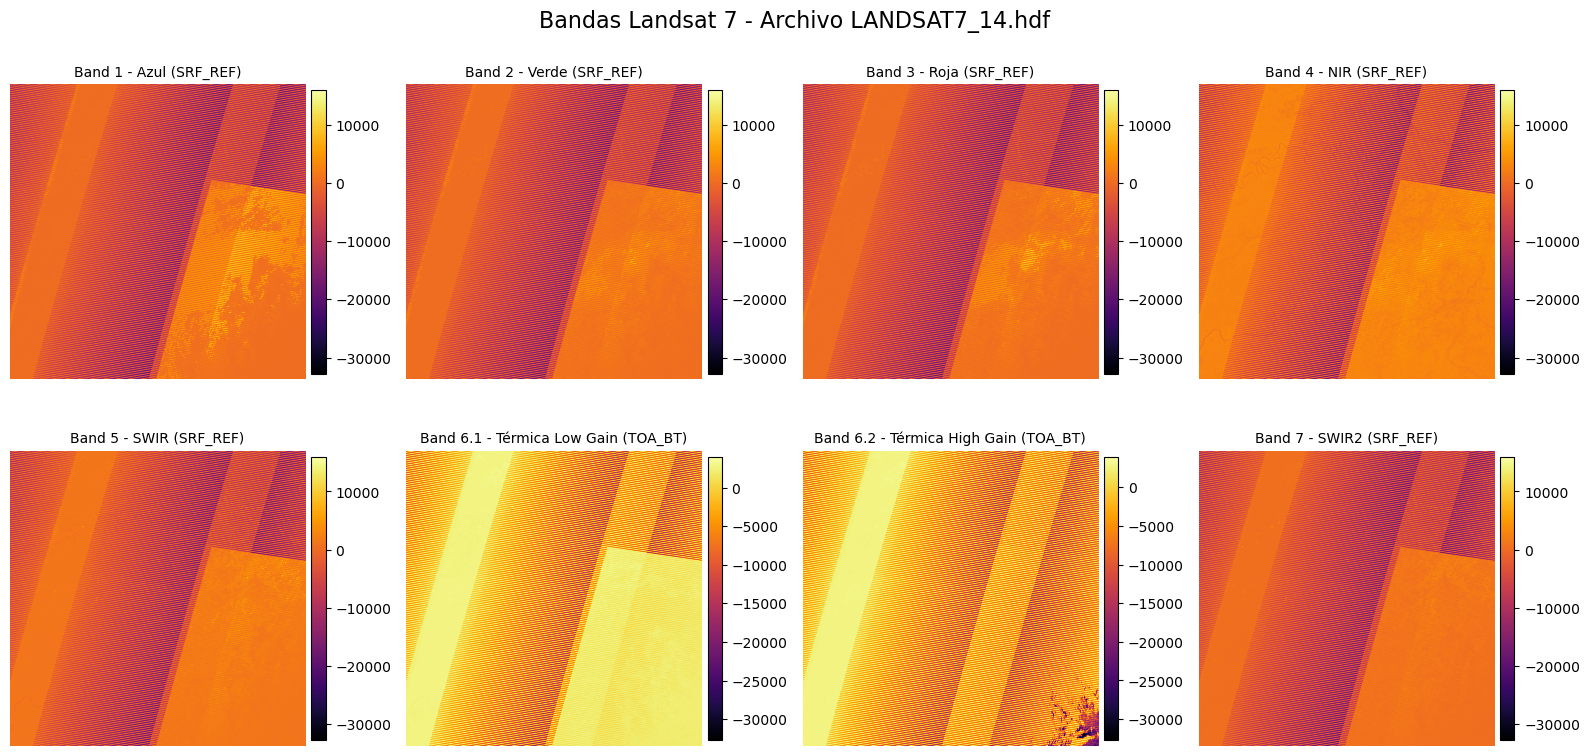

In [3]:
# Organizar las bandas en un diccionario con nombres legibles
bandas = {
    "Band 1 - Azul (SRF_REF)": first_band,
    "Band 2 - Verde (SRF_REF)": second_band,
    "Band 3 - Roja (SRF_REF)": third_band,
    "Band 4 - NIR (SRF_REF)": fourth_band,
    "Band 5 - SWIR (SRF_REF)": fifth_band,
    "Band 6.1 - Térmica Low Gain (TOA_BT)": sixth_a_band,
    "Band 6.2 - Térmica High Gain (TOA_BT)": sixth_b_band,
    "Band 7 - SWIR2 (SRF_REF)": seventh_band
}

# Crear figura
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Mostrar cada banda
for i, (nombre, data) in enumerate(bandas.items()):

    cmap = "inferno"
    
    im = axes[i].imshow(data, cmap=cmap)
    axes[i].set_title(nombre, fontsize=10)
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.045, pad=0.02)

# Ajustar figura
plt.suptitle("Bandas Landsat 7 - Archivo LANDSAT7_14.hdf", fontsize=16)
plt.tight_layout()
plt.show()

## **Diagnóstico de los archivos HDF y conocimiento de las capas**


In [4]:
# CELDA A - DIAGNÓSTICO DE ARCHIVOS HDF
input_folder = "LANDSAT"
hdf_files = sorted(glob.glob(os.path.join(input_folder, "*.hdf")))

print("Ruta de trabajo actual:", os.getcwd())
print("Carpeta buscada:", os.path.abspath(input_folder))
print(f"Archivos .hdf encontrados: {len(hdf_files)}")
for f in hdf_files:
    print(" -", f)

print("\n--- Información de GDAL ---")
try:
    print("GDAL version:", gdal.__version__)
except Exception as e:
    print("No se pudo obtener versión de GDAL:", e)

print("\n--- Intentando abrir cada .hdf con GDAL y listar subdatasets ---")
for path in hdf_files:
    print("\nArchivo:", path)
    ds = gdal.Open(path)
    if ds is None:
        print(" gdal.Open() -> None (GDAL no pudo abrir el archivo).")
    else:
        print(" gdal.Open() -> OK")
        sub = ds.GetSubDatasets()
        print(" Número de SubDatasets:", len(sub))
        for i, s in enumerate(sub):
            print(f"  [{i}] {s[0]}")
    # Intento con pyhdf para que puedas ver datasets internos (HDF4)
    try:
        h = SD(path, SDC.READ)
        dsets = h.datasets()
        print(" pyhdf -> datasets encontrados:", len(dsets))
        for name, info in dsets.items():
            print("  *", name, "| dims:", info[1], "| tipo:", info[3])
    except Exception as e:
        print(" pyhdf -> Error al abrir con pyhdf:", e)


Ruta de trabajo actual: c:\Users\carlo\OneDrive\Documentos\GitHub\Geotermal_Gradient_Multimodal
Carpeta buscada: c:\Users\carlo\OneDrive\Documentos\GitHub\Geotermal_Gradient_Multimodal\LANDSAT
Archivos .hdf encontrados: 76
 - LANDSAT\LANDSAT7_1.hdf
 - LANDSAT\LANDSAT7_10.hdf
 - LANDSAT\LANDSAT7_11.hdf
 - LANDSAT\LANDSAT7_12.hdf
 - LANDSAT\LANDSAT7_13.hdf
 - LANDSAT\LANDSAT7_14.hdf
 - LANDSAT\LANDSAT7_15.hdf
 - LANDSAT\LANDSAT7_16.hdf
 - LANDSAT\LANDSAT7_17.hdf
 - LANDSAT\LANDSAT7_18.hdf
 - LANDSAT\LANDSAT7_19.hdf
 - LANDSAT\LANDSAT7_2.hdf
 - LANDSAT\LANDSAT7_20.hdf
 - LANDSAT\LANDSAT7_21.hdf
 - LANDSAT\LANDSAT7_22.hdf
 - LANDSAT\LANDSAT7_23.hdf
 - LANDSAT\LANDSAT7_24.hdf
 - LANDSAT\LANDSAT7_25.hdf
 - LANDSAT\LANDSAT7_26.hdf
 - LANDSAT\LANDSAT7_27.hdf
 - LANDSAT\LANDSAT7_28.hdf
 - LANDSAT\LANDSAT7_29.hdf
 - LANDSAT\LANDSAT7_3.hdf
 - LANDSAT\LANDSAT7_30.hdf
 - LANDSAT\LANDSAT7_31.hdf
 - LANDSAT\LANDSAT7_32.hdf
 - LANDSAT\LANDSAT7_33.hdf
 - LANDSAT\LANDSAT7_34.hdf
 - LANDSAT\LANDSAT7_35.h

In [5]:
hdf = SD("LANDSAT/LANDSAT7_1.hdf", SDC.READ)
attrs = hdf.attributes()

for k, v in attrs.items():
    print(f"{k}: {v}")

Pixel Size: 30.0
sinus_UL_X: -8895604.158132184
sinus_UL_Y: 317700.5197665226
sinus_UR_X: -8736754.158132184
sinus_UR_Y: 317700.5197665226
sinus_LL_X: -8895604.158132184
sinus_LL_Y: 158850.51976652257
sinus_LR_X: -8736754.158132184
sinus_LR_Y: 158850.51976652257
TileID: hh10vv08.h0v5
L1T_Index_Metadata: BEGIN_L1T_INFO
Totally 4 acquisitions with the following L1T names and scene center solar geometry:
0 LE70100582010012EDC00 center_sz=38.783905 center_sa=130.617523 
1 LE70100592010012EDC00 center_sz=38.018509 center_sa=129.040512 
2 LE70100592010028ASN00 center_sz=37.127041 center_sa=123.264328 
3 LE70110592010003EDC00 center_sz=37.989265 center_sa=131.436539 
END_L1T_INFO

INPUT_POINTER: BEGIN_INPUT_POINTER
Totally 4 acquisitions with the following TOA file names and scene center solar geometry:
0 LE70100582010012EDC00_TOA.v3.0.hdf center_sz=38.783905 center_sa=130.617523 
1 LE70100592010012EDC00_TOA.v3.0.hdf center_sz=38.018509 center_sa=129.040512 
2 LE70100592010028ASN00_TOA.v3.0.h

## **Recorte de los rásters para reducir las dimensiones de las imágenes**

En este caso, se recortarán los rásters para obtener imágenes de las coordenadas específicas en un radio de 20 kilómetros, ya que éstas originalmente tienen unas dimensiones muy grandes.

In [6]:
# Cconfiguración
LANDSAT_DIR = "LANDSAT"
PATTERN = "LANDSAT7_*"
OUT_DIR = "LANDSAT_GEOTIFF"
POINTS_CSV = "data_prep.csv"   # CSV con lon/lat y ID
LON_COL_CANDIDATES = ["Longitude"]
LAT_COL_CANDIDATES = ["Latitude"]
ID_COL_CANDIDATES = ["id","ID","point_id","identifier"]

SIDE_M = 10000.0  # lado en metros (10 km)
DESIRED_BAND_NAMES = [
    "Band1_SRF_REF",
    "Band2_SRF_REF",
    "Band3_SRF_REF",
    "Band4_SRF_REF",
    "Band5_SRF_REF",
    "Band61_TOA_BT",
    "Band62_TOA_BT",
    "Band7_SRF_REF"
]
MAX_BANDS = len(DESIRED_BAND_NAMES)
# ---------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)


def find_column(df, candidates):
    cols = [c.lower() for c in df.columns]
    for cand in candidates:
        if cand.lower() in cols:
            return df.columns[cols.index(cand.lower())]
    return None


def listar_subdatasets_gdal(path):
    ds = gdal.Open(path)
    if ds is None:
        return []
    s = ds.GetSubDatasets() or []
    ds = None
    return s


def sanitize_filename(lon, lat, hdf_basename, idval=None):
    # Si no hay ID, deja el nombre original sin cambios
    if idval is None:
        return os.path.splitext(hdf_basename)[0] + ".tif"
    # Buscar patrón LANDSAT7_* o similar y reemplazar el asterisco o número final
    match = re.match(r"(LANDSAT7_)\d+", hdf_basename, re.IGNORECASE)
    if match:
        base = match.group(1) + str(idval)
    else:
        # Si no coincide el patrón, simplemente concatena
        base = f"{hdf_basename}_{idval}"
    # Sanitizar caracteres especiales
    s = re.sub(r'[^A-Za-z0-9_\-\.]', '_', base)
    return s + ".tif"


def utm_crs_for_lonlat(lon, lat):
    zone = int((lon + 180) / 6) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def find_band_sources_for_names(hdf_path, desired_names):
    sds = listar_subdatasets_gdal(hdf_path)
    desired_lower = [d.lower() for d in desired_names]
    results = []
    if sds:
        sd_entries = [(sname, sdesc, (sdesc + " " + sname).lower()) for (sname, sdesc) in sds]
        for target in desired_lower:
            matched = False
            for sname, sdesc, scombo in sd_entries:
                if target in scombo:
                    results.append(("subds", sname, sdesc.strip()))
                    matched = True
                    break
            if not matched:
                results.append((None, None, None))
        return results
    else:
        try:
            with rasterio.open(hdf_path) as src:
                band_descs = []
                for i in range(1, src.count+1):
                    desc = src.descriptions[i-1] if src.descriptions and src.descriptions[i-1] else f"band{i}"
                    band_descs.append((i, desc, desc.lower()))
                for target in desired_lower:
                    found = False
                    for idx, desc, dlow in band_descs:
                        if target in dlow:
                            results.append(("fileband", (hdf_path, idx), desc))
                            found = True; break
                    if not found:
                        results.append((None, None, None))
                return results
        except Exception:
            return [(None, None, None)] * len(desired_names)


def compute_square_window_pixels(src, lon, lat, side_m=SIDE_M):
    half = side_m / 2.0
    src_crs = src.crs or CRS.from_epsg(4326)
    src_crs_obj = CRS.from_user_input(src_crs)

    if src_crs_obj.is_projected:
        tr = Transformer.from_crs("EPSG:4326", src_crs_obj, always_xy=True)
        x_c, y_c = tr.transform(lon, lat)
        pix_w = abs(src.transform.a); pix_h = abs(src.transform.e)
        px_half = int(math.ceil(half / pix_w))
        py_half = int(math.ceil(half / pix_h))
        target_w = 2 * px_half
        target_h = 2 * py_half
        try:
            row_c, col_c = src.index(x_c, y_c)
        except Exception:
            if (x_c < src.bounds.left) or (x_c > src.bounds.right) or (y_c < src.bounds.bottom) or (y_c > src.bounds.top):
                return None
            col_c = int((x_c - src.bounds.left) / pix_w)
            row_c = int((src.bounds.top - y_c) / pix_h)
        col_off = col_c - px_half
        row_off = row_c - py_half
        return target_w, target_h, col_off, row_off, x_c, y_c, src_crs_obj
    else:
        utm = utm_crs_for_lonlat(lon, lat)
        to_utm = Transformer.from_crs("EPSG:4326", utm, always_xy=True)
        from_utm = Transformer.from_crs(utm, src_crs_obj, always_xy=True)
        ux, uy = to_utm.transform(lon, lat)
        corners_utm = [(ux - half, uy - half), (ux - half, uy + half), (ux + half, uy - half), (ux + half, uy + half)]
        xs = []; ys = []
        for cx, cy in corners_utm:
            x_s, y_s = from_utm.transform(cx, cy)
            xs.append(x_s); ys.append(y_s)
        minx, maxx = min(xs), max(xs); miny, maxy = min(ys), max(ys)
        T = src.transform
        cols = []; rows = []
        for x_s, y_s in [(minx, maxy), (maxx, miny)]:
            try:
                r, c = src.index(x_s, y_s)
            except Exception:
                a = T.a; e = T.e
                c = int((x_s - src.bounds.left) / abs(a))
                r = int((src.bounds.top - y_s) / abs(e))
            cols.append(c); rows.append(r)
        col_min = min(cols); col_max = max(cols)
        row_min = min(rows); row_max = max(rows)
        # estimate center pixel and pixel size in meters
        tr_center = Transformer.from_crs("EPSG:4326", src_crs_obj, always_xy=True)
        x_center_src, y_center_src = tr_center.transform(lon, lat)
        try:
            r_c, c_c = src.index(x_center_src, y_center_src)
        except Exception:
            c_c = int((x_center_src - src.bounds.left) / abs(T.a))
            r_c = int((src.bounds.top - y_center_src) / abs(T.e))
        # approximate meters per pixel using small displacement
        utm2 = utm_crs_for_lonlat(lon, lat)
        to_utm_from_src = Transformer.from_crs(src_crs_obj, utm2, always_xy=True)
        x0 = src.transform.c + src.transform.a * (c_c + 0.5) + src.transform.b * (r_c + 0.5)
        y0 = src.transform.f + src.transform.d * (c_c + 0.5) + src.transform.e * (r_c + 0.5)
        x1 = src.transform.c + src.transform.a * (c_c + 1.5) + src.transform.b * (r_c + 0.5)
        y1 = src.transform.f + src.transform.d * (c_c + 1.5) + src.transform.e * (r_c + 0.5)
        ux0, uy0 = to_utm_from_src.transform(x0, y0)
        ux1, uy1 = to_utm_from_src.transform(x1, y1)
        mpixel = math.hypot(ux1-ux0, uy1-uy0)
        if mpixel <= 0:
            return None
        px_half = int(math.ceil(half / mpixel))
        target_w = 2 * px_half; target_h = 2 * px_half
        col_off = c_c - px_half; row_off = r_c - px_half
        return target_w, target_h, col_off, row_off, x_center_src, y_center_src, src_crs_obj


def read_window_with_padding(src, target_w, target_h, col_off, row_off, fill_value):
    read_col = max(col_off, 0)
    read_row = max(row_off, 0)
    read_w = min(target_w, src.width - read_col) if read_col < src.width else 0
    read_h = min(target_h, src.height - read_row) if read_row < src.height else 0
    out = np.full((target_h, target_w), fill_value, dtype=np.float32)
    if read_w > 0 and read_h > 0:
        dst_col = read_col - col_off
        dst_row = read_row - row_off
        window = Window(read_col, read_row, read_w, read_h)
        try:
            data = src.read(1, window=window, boundless=False, out_shape=(read_h, read_w))
            out[dst_row:dst_row+read_h, dst_col:dst_col+read_w] = data.astype(np.float32)
        except Exception as e:
            print(f"[WARN] read window failed: {e}")
    return out


def create_square_multiband_from_hdf(hdf_path, lon, lat, idval=None, desired_names=DESIRED_BAND_NAMES, out_dir=OUT_DIR, side_m=SIDE_M):
    basename = os.path.splitext(os.path.basename(hdf_path))[0]
    outname = sanitize_filename(lon, lat, basename, idval=idval)
    outpath = os.path.join(out_dir, outname)

    band_map = find_band_sources_for_names(hdf_path, desired_names)

    # Seleccionar una trama de referencia para el cálculo de ventana
    ref_src = None
    for typ, src, desc in band_map:
        if typ == "subds":
            try:
                ref_src = rasterio.open(src); break
            except Exception: continue
        elif typ == "fileband":
            try:
                ref_src = rasterio.open(src[0]); break
            except Exception: continue
    if ref_src is None:
        sds = listar_subdatasets_gdal(hdf_path)
        try:
            ref_src = rasterio.open(sds[0][0]) if sds else rasterio.open(hdf_path)
        except Exception:
            print("[ERROR] No reference raster in", hdf_path); return None

    res = compute_square_window_pixels(ref_src, lon, lat, side_m=side_m)
    if res is None:
        ref_src.close()
        print(f"[INFO] Punto ({lon},{lat}) fuera de bounds en {hdf_path}")
        return None
    target_w, target_h, col_off, row_off, center_x_src, center_y_src, src_crs_obj = res

    nodata_default = -9999
    stacks = []; band_labels = []; nodatas = []
    for entry, label in zip(band_map, desired_names):
        typ, src, desc = entry
        if typ == "subds":
            try:
                with rasterio.open(src) as s:
                    nod = s.nodata if s.nodata is not None else nodata_default
                    arr = read_window_with_padding(s, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr); band_labels.append(desc or label); nodatas.append(nod)
            except Exception as e:
                print(f"[WARN] fallo lectura subds {src}: {e}; llenando nodata")
                stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
                band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)
        elif typ == "fileband":
            path, bidx = src
            try:
                with rasterio.open(path) as s:
                    nod = s.nodata if s.nodata is not None else nodata_default
                    arr = read_window_with_padding(s, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr); band_labels.append(desc or label); nodatas.append(nod)
            except Exception as e:
                print(f"[WARN] fallo lectura fileband {src}: {e}; llenando nodata")
                stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
                band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)
        else:
            stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
            band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)

    ref_crs = ref_src.crs if ref_src.crs is not None else CRS.from_epsg(4326)
    ref_src.close()
    arr_stack = np.stack(stacks, axis=0)

    write_dtype = "float32"
    unique_nodata = set([n for n in nodatas if n is not None])
    nodata_value = unique_nodata.pop() if len(unique_nodata) == 1 else nodata_default

    # calcular out_transform con una apertura temporal para obtener la transformada
    try:
        sds_any = listar_subdatasets_gdal(hdf_path)
        if sds_any:
            tmp = rasterio.open(sds_any[0][0])
        else:
            tmp = rasterio.open(hdf_path)
        out_transform = window_transform(Window(col_off, row_off, target_w, target_h), tmp.transform)
        tmp.close()
    except Exception:
        print("[WARN] no se pudo calcular transform con precisión; intentando fallback")
        # fallback: compute approx using first ref transform
        try:
            tmp2 = rasterio.open(hdf_path if not sds_any else sds_any[0][0])
            out_transform = window_transform(Window(col_off, row_off, target_w, target_h), tmp2.transform)
            tmp2.close()
        except Exception as e:
            print("[ERROR] No pude calcular transform:", e); return None

    try:
        with rasterio.open(outpath, "w", driver="GTiff", height=target_h, width=target_w,
                           count=arr_stack.shape[0], dtype=write_dtype, crs=ref_crs,
                           transform=out_transform, compress="lzw", BIGTIFF="IF_SAFER", nodata=nodata_value) as dst:
            for i in range(arr_stack.shape[0]):
                band_arr = arr_stack[i]
                if np.issubdtype(band_arr.dtype, np.floating):
                    band_arr = np.where(np.isnan(band_arr), nodata_value, band_arr)
                dst.write(band_arr.astype(write_dtype), i+1)
                try:
                    dst.set_band_description(i+1, band_labels[i])
                except Exception:
                    pass
        print("[OK] creado:", outpath)
        return outpath
    except Exception as e:
        print("[ERROR] No pude escribir:", outpath, e)
        return None


def main():
    if not os.path.exists(POINTS_CSV):
        print(f"[ERROR] No existe CSV: {POINTS_CSV}"); return
    dfp = pd.read_csv(POINTS_CSV, sep=";")
    lon_col = find_column(dfp, LON_COL_CANDIDATES)
    lat_col = find_column(dfp, LAT_COL_CANDIDATES)
    id_col = find_column(dfp, ID_COL_CANDIDATES)
    if lon_col is None or lat_col is None:
        print("[ERROR] No se detectaron columnas lon/lat en el CSV. Columnas:", dfp.columns.tolist()); return

    points = []
    for idx, row in dfp.iterrows():
        try:
            lon = float(row[lon_col]); lat = float(row[lat_col])
            pid = str(row[id_col]) if (id_col is not None and not pd.isnull(row[id_col])) else None
            points.append((lon, lat, pid))
        except Exception:
            print(f"[WARN] fila {idx} con datos inválidos; skip")

    archivos = sorted(glob.glob(os.path.join(LANDSAT_DIR, PATTERN + "*")))
    print("HDF encontrados:", len(archivos))
    created = set()
    for f in archivos:
        print("Procesando:", f)
        sds = listar_subdatasets_gdal(f)
        targets = sds if sds else [(f, "direct")]
        for sname, sdesc in targets:
            try:
                with rasterio.open(sname) as src:
                    for lon, lat, pid in points:
                        if src.crs is not None:
                            try:
                                tr = Transformer.from_crs("EPSG:4326", CRS.from_user_input(src.crs), always_xy=True)
                                x, y = tr.transform(lon, lat)
                            except Exception:
                                x, y = lon, lat
                        else:
                            x, y = lon, lat
                        b = src.bounds
                        inside = (x >= b.left and x <= b.right and y >= b.bottom and y <= b.top)
                        if inside:
                            key = (os.path.basename(f), float(lon), float(lat), pid)
                            if key in created:
                                continue
                            out = create_square_multiband_from_hdf(f, lon, lat, idval=pid)
                            if out:
                                created.add(key)
            except Exception as e:
                print("[WARN] fallo inspección target:", e)

    print("Listo. GeoTIFFs en:", OUT_DIR)


if __name__ == "__main__":
    main()

HDF encontrados: 76
Procesando: LANDSAT\LANDSAT7_1.hdf
Procesando: LANDSAT\LANDSAT7_10.hdf
Procesando: LANDSAT\LANDSAT7_11.hdf
Procesando: LANDSAT\LANDSAT7_12.hdf
Procesando: LANDSAT\LANDSAT7_13.hdf
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_416.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_1613.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_1614.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_1615.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3789.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3791.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3797.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3798.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3799.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_3800.tif
Procesando: LANDSAT\LANDSAT7_14.hdf
Procesando: LANDSAT\LANDSAT7_15.hdf
Procesando: LANDSAT\LANDSAT7_16.hdf
Procesando: LANDSAT\LANDSAT7_17.hdf
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_1416.tif
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_1793.tif
Procesando: LANDSAT\LANDSAT7_18.hdf
Procesando: LANDSAT\LANDSAT7_19.hdf
[OK] creado: LANDSAT_G

## **Revisar si hay archivos faltantes**

In [12]:
# Ruta de la carpeta
folder_path = "LANDSAT_GEOTIFF" # Carpeta principal de entrenamiento
#folder_path = "LANDSAT_GEOTIFF_test" # Carpeta principal de prueba

# Rango esperado de archivos
start, end = 1, 4543 # Archivos de entrenamiento
# start, end = 1, 9000 # Archivos de prueba

# Obtener nombres reales de los archivos en la carpeta
existing_files = set(os.listdir(folder_path))

# Crear lista esperada de nombres
expected_files = {f"LANDSAT7_{i}.tif" for i in range(start, end + 1)}

# Calcular los que faltan
missing_files = sorted(list(expected_files - existing_files))

# Mostrar resultados
print(f"Total de archivos esperados: {len(expected_files)}")
print(f"Archivos encontrados: {len(existing_files)}")
print(f"Archivos faltantes: {len(missing_files)}\n")

# Mostrar algunos ejemplos
if missing_files:
    print("Ejemplos de archivos faltantes:")
    print(missing_files[:20])  # muestra los primeros 20
else:
    print("No faltan archivos, todos están presentes.")

# (Opcional) Guardar lista de faltantes en un txt
with open("archivos_faltantes.txt", "w") as f:
    for name in missing_files:
        f.write(name + "\n")


Total de archivos esperados: 4543
Archivos encontrados: 4456
Archivos faltantes: 87

Ejemplos de archivos faltantes:
['LANDSAT7_4452.tif', 'LANDSAT7_4453.tif', 'LANDSAT7_4454.tif', 'LANDSAT7_4455.tif', 'LANDSAT7_4456.tif', 'LANDSAT7_4457.tif', 'LANDSAT7_4458.tif', 'LANDSAT7_4459.tif', 'LANDSAT7_4460.tif', 'LANDSAT7_4461.tif', 'LANDSAT7_4462.tif', 'LANDSAT7_4463.tif', 'LANDSAT7_4464.tif', 'LANDSAT7_4465.tif', 'LANDSAT7_4466.tif', 'LANDSAT7_4467.tif', 'LANDSAT7_4468.tif', 'LANDSAT7_4469.tif', 'LANDSAT7_4470.tif', 'LANDSAT7_4471.tif']


## **Reintento para obtener los recortes**

In [13]:
# Configuración 
LANDSAT_DIR = "LANDSAT"
PATTERN = "LANDSAT7_*"        # Patrón para encontrar HDFs/targets en LANDSAT_DIR
OUT_DIR = "LANDSAT_GEOTIFF"
POINTS_CSV = "data_prep.csv"   # CSV con lon/lat y columna id
MISSING_LIST = "archivos_faltantes.txt"   # Archivo txt que lista los TIFFs que faltan 
LON_COL_CANDIDATES = ["Longitude"]
LAT_COL_CANDIDATES = ["Latitude"]
ID_COL_CANDIDATES = ["id","ID","point_id","identifier"]

SIDE_M = 10000.0  # Lado en metros (10 km)
DESIRED_BAND_NAMES = [
    "Band1_SRF_REF",
    "Band2_SRF_REF",
    "Band3_SRF_REF",
    "Band4_SRF_REF",
    "Band5_SRF_REF",
    "Band61_TOA_BT",
    "Band62_TOA_BT",
    "Band7_SRF_REF"
]
MAX_BANDS = len(DESIRED_BAND_NAMES)
# ---------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)


def find_column(df, candidates):
    cols = [c.lower() for c in df.columns]
    for cand in candidates:
        if cand.lower() in cols:
            return df.columns[cols.index(cand.lower())]
    return None


def listar_subdatasets_gdal(path):
    ds = gdal.Open(path)
    if ds is None:
        return []
    s = ds.GetSubDatasets() or []
    ds = None
    return s


def sanitize_filename(lon, lat, hdf_basename, idval=None):
    # Si no hay ID, deja el nombre original sin cambios
    if idval is None:
        return os.path.splitext(hdf_basename)[0] + ".tif"
    # Buscar patrón LANDSAT7_* o similar y reemplazar el número final
    match = re.match(r"(LANDSAT7_)\d+", hdf_basename, re.IGNORECASE)
    if match:
        base = match.group(1) + str(idval)
    else:
        # Si no coincide el patrón, simplemente concatena
        base = f"{hdf_basename}_{idval}"
    # Sanitizar caracteres especiales
    s = re.sub(r'[^A-Za-z0-9_\-\.]', '_', base)
    return s + ".tif"


def utm_crs_for_lonlat(lon, lat):
    zone = int((lon + 180) / 6) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def find_band_sources_for_names(hdf_path, desired_names):
    sds = listar_subdatasets_gdal(hdf_path)
    desired_lower = [d.lower() for d in desired_names]
    results = []
    if sds:
        sd_entries = [(sname, sdesc, (sdesc + " " + sname).lower()) for (sname, sdesc) in sds]
        for target in desired_lower:
            matched = False
            for sname, sdesc, scombo in sd_entries:
                if target in scombo:
                    results.append(("subds", sname, sdesc.strip()))
                    matched = True
                    break
            if not matched:
                results.append((None, None, None))
        return results
    else:
        try:
            with rasterio.open(hdf_path) as src:
                band_descs = []
                for i in range(1, src.count+1):
                    desc = src.descriptions[i-1] if src.descriptions and src.descriptions[i-1] else f"band{i}"
                    band_descs.append((i, desc, desc.lower()))
                for target in desired_lower:
                    found = False
                    for idx, desc, dlow in band_descs:
                        if target in dlow:
                            results.append(("fileband", (hdf_path, idx), desc))
                            found = True; break
                    if not found:
                        results.append((None, None, None))
                return results
        except Exception:
            return [(None, None, None)] * len(desired_names)


def compute_square_window_pixels(src, lon, lat, side_m=SIDE_M):
    half = side_m / 2.0
    src_crs = src.crs or CRS.from_epsg(4326)
    src_crs_obj = CRS.from_user_input(src_crs)

    if src_crs_obj.is_projected:
        tr = Transformer.from_crs("EPSG:4326", src_crs_obj, always_xy=True)
        x_c, y_c = tr.transform(lon, lat)
        pix_w = abs(src.transform.a); pix_h = abs(src.transform.e)
        px_half = int(math.ceil(half / pix_w))
        py_half = int(math.ceil(half / pix_h))
        target_w = 2 * px_half
        target_h = 2 * py_half
        try:
            row_c, col_c = src.index(x_c, y_c)
        except Exception:
            if (x_c < src.bounds.left) or (x_c > src.bounds.right) or (y_c < src.bounds.bottom) or (y_c > src.bounds.top):
                return None
            col_c = int((x_c - src.bounds.left) / pix_w)
            row_c = int((src.bounds.top - y_c) / pix_h)
        col_off = col_c - px_half
        row_off = row_c - py_half
        return target_w, target_h, col_off, row_off, x_c, y_c, src_crs_obj
    else:
        utm = utm_crs_for_lonlat(lon, lat)
        to_utm = Transformer.from_crs("EPSG:4326", utm, always_xy=True)
        from_utm = Transformer.from_crs(utm, src_crs_obj, always_xy=True)
        ux, uy = to_utm.transform(lon, lat)
        corners_utm = [(ux - half, uy - half), (ux - half, uy + half), (ux + half, uy - half), (ux + half, uy + half)]
        xs = []; ys = []
        for cx, cy in corners_utm:
            x_s, y_s = from_utm.transform(cx, cy)
            xs.append(x_s); ys.append(y_s)
        minx, maxx = min(xs), max(xs); miny, maxy = min(ys), max(ys)
        T = src.transform
        cols = []; rows = []
        for x_s, y_s in [(minx, maxy), (maxx, miny)]:
            try:
                r, c = src.index(x_s, y_s)
            except Exception:
                a = T.a; e = T.e
                c = int((x_s - src.bounds.left) / abs(a))
                r = int((src.bounds.top - y_s) / abs(e))
            cols.append(c); rows.append(r)
        col_min = min(cols); col_max = max(cols)
        row_min = min(rows); row_max = max(rows)
        # estimate center pixel and pixel size in meters
        tr_center = Transformer.from_crs("EPSG:4326", src_crs_obj, always_xy=True)
        x_center_src, y_center_src = tr_center.transform(lon, lat)
        try:
            r_c, c_c = src.index(x_center_src, y_center_src)
        except Exception:
            c_c = int((x_center_src - src.bounds.left) / abs(T.a))
            r_c = int((src.bounds.top - y_center_src) / abs(T.e))
        # approximate meters per pixel using small displacement
        utm2 = utm_crs_for_lonlat(lon, lat)
        to_utm_from_src = Transformer.from_crs(src_crs_obj, utm2, always_xy=True)
        x0 = src.transform.c + src.transform.a * (c_c + 0.5) + src.transform.b * (r_c + 0.5)
        y0 = src.transform.f + src.transform.d * (c_c + 0.5) + src.transform.e * (r_c + 0.5)
        x1 = src.transform.c + src.transform.a * (c_c + 1.5) + src.transform.b * (r_c + 0.5)
        y1 = src.transform.f + src.transform.d * (c_c + 1.5) + src.transform.e * (r_c + 0.5)
        ux0, uy0 = to_utm_from_src.transform(x0, y0)
        ux1, uy1 = to_utm_from_src.transform(x1, y1)
        mpixel = math.hypot(ux1-ux0, uy1-uy0)
        if mpixel <= 0:
            return None
        px_half = int(math.ceil(half / mpixel))
        target_w = 2 * px_half; target_h = 2 * px_half
        col_off = c_c - px_half; row_off = r_c - px_half
        return target_w, target_h, col_off, row_off, x_center_src, y_center_src, src_crs_obj


def read_window_with_padding(src, target_w, target_h, col_off, row_off, fill_value):
    read_col = max(col_off, 0)
    read_row = max(row_off, 0)
    read_w = min(target_w, src.width - read_col) if read_col < src.width else 0
    read_h = min(target_h, src.height - read_row) if read_row < src.height else 0
    out = np.full((target_h, target_w), fill_value, dtype=np.float32)
    if read_w > 0 and read_h > 0:
        dst_col = read_col - col_off
        dst_row = read_row - row_off
        window = Window(read_col, read_row, read_w, read_h)
        try:
            data = src.read(1, window=window, boundless=False, out_shape=(read_h, read_w))
            out[dst_row:dst_row+read_h, dst_col:dst_col+read_w] = data.astype(np.float32)
        except Exception as e:
            print(f"[WARN] read window failed: {e}")
    return out


def create_square_multiband_from_hdf(hdf_path, lon, lat, idval=None, desired_names=DESIRED_BAND_NAMES, out_dir=OUT_DIR, side_m=SIDE_M):
    basename = os.path.splitext(os.path.basename(hdf_path))[0]
    outname = sanitize_filename(lon, lat, basename, idval=idval)
    outpath = os.path.join(out_dir, outname)

    band_map = find_band_sources_for_names(hdf_path, desired_names)

    # choose a reference raster for window calc
    ref_src = None
    for typ, src, desc in band_map:
        if typ == "subds":
            try:
                ref_src = rasterio.open(src); break
            except Exception: continue
        elif typ == "fileband":
            try:
                ref_src = rasterio.open(src[0]); break
            except Exception: continue
    if ref_src is None:
        sds = listar_subdatasets_gdal(hdf_path)
        try:
            ref_src = rasterio.open(sds[0][0]) if sds else rasterio.open(hdf_path)
        except Exception:
            print("[ERROR] No reference raster in", hdf_path); return None

    res = compute_square_window_pixels(ref_src, lon, lat, side_m=side_m)
    if res is None:
        ref_src.close()
        print(f"[INFO] Punto ({lon},{lat}) fuera de bounds en {hdf_path}")
        return None
    target_w, target_h, col_off, row_off, center_x_src, center_y_src, src_crs_obj = res

    nodata_default = -9999
    stacks = []; band_labels = []; nodatas = []
    for entry, label in zip(band_map, desired_names):
        typ, src, desc = entry
        if typ == "subds":
            try:
                with rasterio.open(src) as s:
                    nod = s.nodata if s.nodata is not None else nodata_default
                    arr = read_window_with_padding(s, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr); band_labels.append(desc or label); nodatas.append(nod)
            except Exception as e:
                print(f"[WARN] fallo lectura subds {src}: {e}; llenando nodata")
                stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
                band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)
        elif typ == "fileband":
            path, bidx = src
            try:
                with rasterio.open(path) as s:
                    nod = s.nodata if s.nodata is not None else nodata_default
                    arr = read_window_with_padding(s, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr); band_labels.append(desc or label); nodatas.append(nod)
            except Exception as e:
                print(f"[WARN] fallo lectura fileband {src}: {e}; llenando nodata")
                stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
                band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)
        else:
            stacks.append(np.full((target_h, target_w), nodata_default, dtype=np.float32))
            band_labels.append(label + "_MISSING"); nodatas.append(nodata_default)

    ref_crs = ref_src.crs if ref_src.crs is not None else CRS.from_epsg(4326)
    ref_src.close()
    arr_stack = np.stack(stacks, axis=0)

    write_dtype = "float32"
    unique_nodata = set([n for n in nodatas if n is not None])
    nodata_value = unique_nodata.pop() if len(unique_nodata) == 1 else nodata_default

    # compute out_transform with a temporary open to get transform
    try:
        sds_any = listar_subdatasets_gdal(hdf_path)
        if sds_any:
            tmp = rasterio.open(sds_any[0][0])
        else:
            tmp = rasterio.open(hdf_path)
        out_transform = window_transform(Window(col_off, row_off, target_w, target_h), tmp.transform)
        tmp.close()
    except Exception:
        print("[WARN] no se pudo calcular transform con precisión; intentando fallback")
        try:
            tmp2 = rasterio.open(hdf_path if not sds_any else sds_any[0][0])
            out_transform = window_transform(Window(col_off, row_off, target_w, target_h), tmp2.transform)
            tmp2.close()
        except Exception as e:
            print("[ERROR] No pude calcular transform:", e); return None

    try:
        with rasterio.open(outpath, "w", driver="GTiff", height=target_h, width=target_w,
                           count=arr_stack.shape[0], dtype=write_dtype, crs=ref_crs,
                           transform=out_transform, compress="lzw", BIGTIFF="IF_SAFER", nodata=nodata_value) as dst:
            for i in range(arr_stack.shape[0]):
                band_arr = arr_stack[i]
                if np.issubdtype(band_arr.dtype, np.floating):
                    band_arr = np.where(np.isnan(band_arr), nodata_value, band_arr)
                dst.write(band_arr.astype(write_dtype), i+1)
                try:
                    dst.set_band_description(i+1, band_labels[i])
                except Exception:
                    pass
        print("[OK] creado:", outpath)
        return outpath
    except Exception as e:
        print("[ERROR] No pude escribir:", outpath, e)
        return None


# --- utilidades para el workflow con missing.txt ---

def normalize_id_value(v):
    if pd.isnull(v):
        return None
    s = str(v).strip()
    # quitar .0 de floats como '116.0'
    if re.match(r"^\d+\.0+$", s):
        s = s.split('.')[0]
    m = re.search(r"(\d+)$", s)
    if m:
        return m.group(1)
    return s


def id_from_tif_name(name):
    # ejemplo: LANDSAT7_1116.tif -> '1116'
    m = re.search(r"_(\d+)(?=\.tif$)", name, re.IGNORECASE)
    if m:
        return m.group(1)
    m2 = re.search(r"(\d+)", name)
    return m2.group(1) if m2 else None


def main():
    if not os.path.exists(POINTS_CSV):
        print(f"[ERROR] No existe CSV: {POINTS_CSV}"); return
    if not os.path.exists(MISSING_LIST):
        print(f"[ERROR] No existe la lista de missing: {MISSING_LIST}"); return

    # leer CSV de puntos
    dfp = pd.read_csv(POINTS_CSV, sep=';')
    lon_col = find_column(dfp, LON_COL_CANDIDATES)
    lat_col = find_column(dfp, LAT_COL_CANDIDATES)
    id_col = find_column(dfp, ID_COL_CANDIDATES)
    if lon_col is None or lat_col is None:
        print("[ERROR] No se detectaron columnas lon/lat en el CSV. Columnas:", dfp.columns.tolist()); return

    # leer missing.txt
    with open(MISSING_LIST, 'r', encoding='utf-8') as fh:
        lines = [l.strip() for l in fh.readlines()]
    missing_names = [l for l in lines if l]
    missing_ids = {}
    for name in missing_names:
        idstr = id_from_tif_name(name)
        if idstr:
            missing_ids[idstr] = name
        else:
            print(f"[WARN] no pude extraer ID de nombre: {name}")

    if not missing_ids:
        print("[INFO] No hay IDs extraíbles en el archivo missing."); return

    # construir diccionario id -> (lon,lat,original_id_value)
    requested = {}
    for idx, row in dfp.iterrows():
        if id_col is not None and not pd.isnull(row[id_col]):
            row_id_norm = normalize_id_value(row[id_col])
            if row_id_norm in missing_ids:
                try:
                    lon = float(row[lon_col]); lat = float(row[lat_col])
                    requested[row_id_norm] = (lon, lat, row[id_col])
                except Exception:
                    print(f"[WARN] fila {idx} con coordenadas inválidas; skip")
        else:
            # si no hay id_col, como último recurso usar el índice (string)
            idx_key = str(idx)
            if idx_key in missing_ids:
                try:
                    lon = float(row[lon_col]); lat = float(row[lat_col])
                    requested[idx_key] = (lon, lat, idx)
                except Exception:
                    print(f"[WARN] fila {idx} con coordenadas inválidas; skip")

    # revisar IDs solicitados que no se encontraron en el CSV
    not_found = [iid for iid in missing_ids.keys() if iid not in requested]
    if not_found:
        print(f"[WARN] Algunos IDs listados en {MISSING_LIST} no se encontraron en {POINTS_CSV}:", not_found)

    archivos = sorted(glob.glob(os.path.join(LANDSAT_DIR, PATTERN + "*")))
    print("HDF encontrados:", len(archivos))

    remaining = set(requested.keys())
    created = set()

    for f in archivos:
        if not remaining:
            break
        # inspeccionar si este HDF puede contener alguno de los puntos restantes
        try:
            sds = listar_subdatasets_gdal(f)
            targets = sds if sds else [(f, "direct")]
            any_inside = False
            # quick bounds check: open first subdataset or file to test bounds
            test_open = None
            try:
                if sds:
                    test_open = rasterio.open(sds[0][0])
                else:
                    test_open = rasterio.open(f)
            except Exception:
                test_open = None

            if test_open is None:
                # no referencia posible, skip
                continue

            # check each remaining point against bounds of this file
            bounds = test_open.bounds
            for iid in list(remaining):
                lon, lat, orig_id = requested[iid]
                try:
                    if test_open.crs is not None:
                        tr = Transformer.from_crs("EPSG:4326", CRS.from_user_input(test_open.crs), always_xy=True)
                        x, y = tr.transform(lon, lat)
                    else:
                        x, y = lon, lat
                    b = bounds
                    inside = (x >= b.left and x <= b.right and y >= b.bottom and y <= b.top)
                except Exception:
                    inside = False
                if inside:
                    any_inside = True
                    break

            test_open.close()
            if not any_inside:
                # este archivo no contiene ninguno de los puntos restantes
                continue

            # procesar targets
            for sname, sdesc in targets:
                try:
                    with rasterio.open(sname) as src:
                        for iid in list(remaining):
                            lon, lat, orig_id = requested[iid]
                            if src.crs is not None:
                                try:
                                    tr = Transformer.from_crs("EPSG:4326", CRS.from_user_input(src.crs), always_xy=True)
                                    x, y = tr.transform(lon, lat)
                                except Exception:
                                    x, y = lon, lat
                            else:
                                x, y = lon, lat
                            b = src.bounds
                            inside = (x >= b.left and x <= b.right and y >= b.bottom and y <= b.top)
                            if inside:
                                # pid for filename: prefer the normalized numeric string
                                try:
                                    pid_for_name = int(iid)
                                except Exception:
                                    pid_for_name = requested[iid][2]
                                out = create_square_multiband_from_hdf(f, lon, lat, idval=pid_for_name)
                                if out:
                                    created.add(iid)
                                    remaining.discard(iid)
                except Exception as e:
                    print("[WARN] fallo inspección target:", e)
        except Exception as e:
            print("[WARN] fallo inspección archivo:", f, e)

    if remaining:
        print("[WARN] No pude crear los siguientes IDs (no encontrados en ningún HDF o falló el recorte):", list(remaining))
    else:
        print("[OK] Todos los TIFFs solicitados fueron creados o encontrados.")

    print("Listo. GeoTIFFs en:", OUT_DIR)


if __name__ == "__main__":
    main()


HDF encontrados: 76
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,271)
[OK] creado: LANDSAT_GEOTIFF\LANDSAT7_4535.tif
[WARN] read window failed: could not broadcast input array from shape (334,334) into shape (334,263)
[WARN] read window faile

# **Revisión de todos los archivos**

En este caso, se hace un recorrido para ver si hay archivos faltantes o incorrectos (bandas sin datos o con gran porcentaje de datos faltantes). En el caso de que se encuentren, hay un código para esos archivos que intenta obtenerlos en base a los problemas encontrados.

In [14]:
# Configuración
OUT_DIR = "LANDSAT_GEOTIFF"
DESIRED_BAND_NAMES = [
    "Band1_SRF_REF",
    "Band2_SRF_REF",
    "Band3_SRF_REF",
    "Band4_SRF_REF",
    "Band5_SRF_REF",
    "Band61_TOA_BT",
    "Band62_TOA_BT",
    "Band7_SRF_REF"
]
MAX_BANDS = len(DESIRED_BAND_NAMES)
OUT_REPORT = "archivos_incorrectos.txt"
# Tamaño máximo (filas/cols) para leer por banda 
MAX_SAMPLE_DIM = 256
# ----------------------------------------------------------------

# función para chequear un archivo TIFF
def check_tif(path):
    motivos = []
    try:
        with rasterio.open(path) as src:
            # 1) Abre bien -> comprobamos número de bandas
            if src.count != MAX_BANDS:
                motivos.append(f"band_count={src.count} (esperado={MAX_BANDS})")

            # obtener descripciones de bandas
            descs = src.descriptions or [None] * src.count
            descs_lower = [ (d.lower() if d else "") for d in descs ]

            # 2) Comprobar descripciones esperadas (por substring)
            for wanted in DESIRED_BAND_NAMES:
                wl = wanted.lower()
                found = False
                for d in descs_lower:
                    if wl in d:
                        found = True
                        break
                if not found:
                    motivos.append(f"desc_missing:{wanted}")

            # 3) Comprobar que cada banda tenga al menos algun píxel válido (no-nodata)
            # leer versión reducida de la banda para rendimiento
            sample_rows = min(MAX_SAMPLE_DIM, src.height)
            sample_cols = min(MAX_SAMPLE_DIM, src.width)
            # si el raster es muy pequeño, leemos completo; si no, rasterio reescalará.
            for i in range(1, src.count + 1):
                nod_vals = src.nodatavals[i-1] if src.nodatavals else None
                try:
                    data = src.read(i, masked=True, out_shape=(sample_rows, sample_cols))
                    if np.ma.is_masked(data):
                        if data.mask.all():
                            motivos.append(f"band_all_nodata:band{i}")
                        else:
                            # hay al menos algún dato válido en la muestra
                            pass
                    else:
                        if nod_vals is not None:
                            if np.all(data == nod_vals):
                                motivos.append(f"band_all_nodata:band{i}")
                        else:
                            # sin nodata declarado, comprobamos NaN (si float) o unicidad
                            if np.issubdtype(data.dtype, np.floating):
                                if np.isnan(data).all():
                                    motivos.append(f"band_all_nan:band{i}")
                            else:
                                # si todos los píxeles tienen el mismo valor (poco probable que sea válido)
                                if np.unique(data).size == 1:
                                    motivos.append(f"band_constant_value:band{i} (valor={np.unique(data)[0]})")
                except Exception as e:
                    motivos.append(f"read_error_band{i}:{e}")
    except Exception as e:
        motivos.append(f"open_error:{e}")

    seen = set()
    motivos_clean = []
    for m in motivos:
        if m not in seen:
            motivos_clean.append(m); seen.add(m)
    return motivos_clean


def main():
    if not os.path.isdir(OUT_DIR):
        print(f"[ERROR] OUT_DIR no existe: {OUT_DIR}")
        return

    tifs = sorted(glob.glob(os.path.join(OUT_DIR, "*.tif")))
    print(f"[INFO] encontrados {len(tifs)} .tif en {OUT_DIR}")

    bad_entries = []
    good_count = 0

    for p in tifs:
        motivos = check_tif(p)
        if motivos:
            bad_entries.append((p, motivos))
            print(f"[BAD] {os.path.basename(p)} -> {'; '.join(motivos)}")
        else:
            good_count += 1

    # Escribir reporte
    with open(OUT_REPORT, "w", encoding="utf-8") as fh:
        for p, motivos in bad_entries:
            fh.write(f"{p}\t{'; '.join(motivos)}\n")

    print(f"\nResumen: buenos={good_count}, malos={len(bad_entries)}. Reporte: {OUT_REPORT}")

if __name__ == "__main__":
    main()


[INFO] encontrados 4543 .tif en LANDSAT_GEOTIFF
[BAD] LANDSAT7_4534.tif -> band_all_nodata:band1; band_all_nodata:band2; band_all_nodata:band3; band_all_nodata:band4; band_all_nodata:band5; band_all_nodata:band6; band_all_nodata:band7; band_all_nodata:band8
[BAD] LANDSAT7_4535.tif -> band_all_nodata:band1; band_all_nodata:band2; band_all_nodata:band3; band_all_nodata:band4; band_all_nodata:band5; band_all_nodata:band6; band_all_nodata:band7; band_all_nodata:band8

Resumen: buenos=4541, malos=2. Reporte: archivos_incorrectos.txt


In [16]:
# Configuración
OUT_DIR = "LANDSAT_GEOTIFF"
REPORT = "diagnostico_tiffs_report.txt"

tifs = sorted(glob.glob(os.path.join(OUT_DIR, "*.tif")))
lines = []
for p in tifs:
    try:
        with rasterio.open(p) as src:
            info = f"{os.path.basename(p)} | bands={src.count} | shape={src.width}x{src.height} | dtype={src.dtypes[0]}"
            lines.append(info)
            for i in range(1, src.count+1):
                nod = src.nodatavals[i-1] if src.nodatavals else None
                # leer una muestra para no cargar todo si es muy grande
                rows = min(1024, src.height)
                cols = min(1024, src.width)
                try:
                    data = src.read(i, out_shape=(rows, cols), masked=True, boundless=True)
                except Exception:
                    # fallback: leer todo (solo si pequeños)
                    data = src.read(i, masked=True)
                if np.ma.is_masked(data):
                    valid_mask = ~data.mask
                    n_valid = int(valid_mask.sum())
                    n_total = data.size
                else:
                    if nod is not None:
                        valid_mask = data != nod
                        n_valid = int(valid_mask.sum())
                        n_total = data.size
                    else:
                        n_valid = int(np.isfinite(data).sum())
                        n_total = data.size
                pct_valid = 100.0 * n_valid / n_total if n_total>0 else 0.0
                stats = ""
                if n_valid > 0:
                    # compute stats on the sample (masked array)
                    try:
                        if np.ma.is_masked(data):
                            arr = data.data[~data.mask]
                        else:
                            arr = data.flatten()
                        mn = float(np.min(arr)); mx = float(np.max(arr)); mean = float(np.mean(arr))
                        stats = f"min={mn:.6g} max={mx:.6g} mean={mean:.6g}"
                    except Exception:
                        stats = "stats_err"
                else:
                    stats = "all_nodata"
                lines.append(f"  band{i}: nodata={nod} | valid_sample={n_valid}/{n_total} ({pct_valid:.2f}%) | {stats}")
    except Exception as e:
        lines.append(f"{os.path.basename(p)} | ERROR_OPEN: {e}")

with open(REPORT, "w", encoding="utf-8") as fh:
    fh.write("\n".join(lines))
print("Hecho. Reporte:", REPORT)


Hecho. Reporte: diagnostico_tiffs_report.txt


In [15]:
# Configuración
LANDSAT_DIR = "LANDSAT"
PATTERN = "LANDSAT7_*"
OUT_DIR = "LANDSAT_GEOTIFF_2"
POINTS_CSV = "data_prep.csv"
ARCHIVOS_INCORRECTOS = "archivos_incorrectos.txt"

LON_COL_CANDIDATES = ["Longitude"]
LAT_COL_CANDIDATES = ["Latitude"]
ID_COL_CANDIDATES = ["id","ID","point_id","identifier"]

SIDE_M = 10000.0  # Lado del recorte
DESIRED_BAND_NAMES = [
    "Band1_SRF_REF","Band2_SRF_REF","Band3_SRF_REF","Band4_SRF_REF",
    "Band5_SRF_REF","Band61_TOA_BT","Band62_TOA_BT","Band7_SRF_REF"
]

os.makedirs(OUT_DIR, exist_ok=True)

# Utilidades
def find_column(df, candidates):
    cols = [c.lower() for c in df.columns]
    for cand in candidates:
        if cand.lower() in cols:
            return df.columns[cols.index(cand.lower())]
    return None


def listar_subdatasets_gdal(path):
    try:
        ds = gdal.Open(path)
        if ds is None: 
            return []
        s = ds.GetSubDatasets() or []
        ds = None
        return s
    except Exception:
        return []


def id_from_tif_name(name):
    m = re.search(r"_(\d+)(?=\.tif$)", name, re.IGNORECASE)
    if m: return m.group(1)
    m2 = re.search(r"(\d+)", name)
    return m2.group(1) if m2 else None


def normalize_id_value(v):
    if pd.isnull(v): return None
    s = str(v).strip()
    if re.match(r"^\d+\.0+$", s): s = s.split('.')[0]
    m = re.search(r"(\d+)$", s)
    return m.group(1) if m else s


def sanitize_filename(lon, lat, hdf_basename, idval=None):
    if idval is None:
        return os.path.splitext(hdf_basename)[0] + ".tif"

    match = re.match(r"(LANDSAT7_)\d+", hdf_basename, re.IGNORECASE)
    if match:
        base = match.group(1) + str(idval)
    else:
        base = f"{hdf_basename}_{idval}"

    s = re.sub(r'[^A-Za-z0-9_\-\.]', '_', base)
    return s + ".tif"


def compute_square_window_pixels(src, lon, lat, side_m=SIDE_M):
    half = side_m/2.0

    src_crs = src.crs or CRS.from_epsg(4326)
    src_crs_obj = CRS.from_user_input(src_crs)

    tr = Transformer.from_crs("EPSG:4326", src_crs_obj, always_xy=True)
    x_c, y_c = tr.transform(lon, lat)

    pix_w = abs(src.transform.a)
    pix_h = abs(src.transform.e)

    px_half = int(math.ceil(half / pix_w))
    py_half = int(math.ceil(half / pix_h))
    target_w = 2*px_half
    target_h = 2*py_half

    try:
        row_c, col_c = src.index(x_c, y_c)
    except:
        b = src.bounds
        if (x_c < b.left) or (x_c > b.right) or (y_c < b.bottom) or (y_c > b.top):
            return None

        col_c = int((x_c - b.left) / pix_w)
        row_c = int((src.bounds.top - y_c) / pix_h)

    return target_w, target_h, col_c - px_half, row_c - py_half, x_c, y_c, src_crs_obj

# Función arreglada para leer ventanas (offsets negativos validos)
def read_window_fixed(src, band_index, target_w, target_h, col_off, row_off, fill_value):
    """
    Lee una ventana posiblemente fuera del raster, devolviendo SIEMPRE
    un array target_h × target_w, usando boundless=True.
    """
    win = Window(col_off, row_off, target_w, target_h)

    data = src.read(
        band_index,
        window=win,
        boundless=True,
        fill_value=fill_value
    )

    return data.astype(np.float32)


def find_band_sources_for_names(hdf_path, desired_names):
    sds = listar_subdatasets_gdal(hdf_path)
    desired_lower = [d.lower() for d in desired_names]

    results = []

    if sds:
        entries = [(sname, sdesc, (sdesc + " " + sname).lower()) for (sname, sdesc) in sds]

        for target in desired_lower:
            matched = False
            for sname, sdesc, scombo in entries:
                if target in scombo:
                    results.append(("subds", sname, sdesc.strip()))
                    matched = True
                    break
            if not matched:
                results.append((None, None, None))
        return results

    # no subdatasets: intentar abrir como raster normal
    try:
        with rasterio.open(hdf_path) as src:
            band_descs = []
            for i in range(1, src.count+1):
                desc = src.descriptions[i-1] if src.descriptions and src.descriptions[i-1] else f"band{i}"
                band_descs.append((i, desc, desc.lower()))

            for target in desired_lower:
                matched = False
                for idx, desc, dlow in band_descs:
                    if target in dlow:
                        results.append(("fileband", (hdf_path, idx), desc))
                        matched = True
                        break
                if not matched:
                    results.append((None, None, None))
    except:
        results = [(None, None, None)] * len(desired_names)

    return results

# Función principal que genera el TIFF
def create_square_multiband_from_hdf(hdf_path, lon, lat, idval=None):
    basename = os.path.splitext(os.path.basename(hdf_path))[0]
    outname = sanitize_filename(lon, lat, basename, idval=idval)
    outpath = os.path.join(OUT_DIR, outname)

    band_map = find_band_sources_for_names(hdf_path, DESIRED_BAND_NAMES)

    ref_src = None
    for typ, src, desc in band_map:
        try:
            if typ == "subds":
                ref_src = rasterio.open(src)
                break
            elif typ == "fileband":
                ref_src = rasterio.open(src[0])
                break
        except:
            continue

    if ref_src is None:
        return None, "NO se pudo abrir ningún subdataset como referencia"

    window = compute_square_window_pixels(ref_src, lon, lat)
    if window is None:
        ref_src.close()
        return None, "PUNTO FUERA DE LA IMAGEN"

    target_w, target_h, col_off, row_off, _, _, _ = window

    nodata_default = -32768
    stacks = []
    labels = []

    for typ, src, desc in band_map:
        if typ == "subds":
            try:
                with rasterio.open(src) as s:
                    nod = s.nodata or nodata_default
                    arr = read_window_fixed(s, 1, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr)
                    labels.append(desc)
            except:
                stacks.append(np.full((target_h, target_w), nodata_default))
                labels.append(desc+"_MISSING")

        elif typ == "fileband":
            path, bidx = src
            try:
                with rasterio.open(path) as s:
                    nod = s.nodata or nodata_default
                    arr = read_window_fixed(s, bidx, target_w, target_h, col_off, row_off, nod)
                    stacks.append(arr)
                    labels.append(desc)
            except:
                stacks.append(np.full((target_h, target_w), nodata_default))
                labels.append(desc+"_MISSING")

        else:
            stacks.append(np.full((target_h, target_w), nodata_default))
            labels.append("MISSING")

    arr_stack = np.stack(stacks, axis=0)

    transform = window_transform(
        Window(col_off, row_off, target_w, target_h),
        ref_src.transform
    )
    crs = ref_src.crs
    ref_src.close()

    with rasterio.open(
        outpath, "w", driver="GTiff",
        height=target_h, width=target_w,
        count=arr_stack.shape[0],
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=nodata_default,
        compress="lzw"
    ) as dst:
        for i in range(arr_stack.shape[0]):
            dst.write(arr_stack[i], i+1)
            try:
                dst.set_band_description(i+1, labels[i])
            except:
                pass

    return outpath, "OK"

# Procesamiento
def run_regeneration():
    if not os.path.exists(ARCHIVOS_INCORRECTOS):
        print("No existe", ARCHIVOS_INCORRECTOS)
        return

    df_points = pd.read_csv(POINTS_CSV, sep=";")

    lon_col = find_column(df_points, LON_COL_CANDIDATES)
    lat_col = find_column(df_points, LAT_COL_CANDIDATES)
    id_col  = find_column(df_points, ID_COL_CANDIDATES)

    hdfs = sorted(glob.glob(os.path.join(LANDSAT_DIR, PATTERN + "*")))

    with open(ARCHIVOS_INCORRECTOS, "r", encoding="utf-8") as fh:
        lines = [l.strip() for l in fh if l.strip()]

    for ln in lines:
        parts = ln.split("\t")
        tifname = parts[0]
        tid = id_from_tif_name(os.path.basename(tifname))

        lon = lat = None
        if tid and id_col:
            match = df_points[df_points[id_col].apply(lambda v: normalize_id_value(v) == tid)]
            if len(match) > 0:
                lon = float(match.iloc[0][lon_col])
                lat = float(match.iloc[0][lat_col])

        # Buscar el HDF correcto
        candidates = []
        if lon is not None and lat is not None:
            for h in hdfs:
                try:
                    sds = listar_subdatasets_gdal(h)
                    test = rasterio.open(sds[0][0]) if sds else rasterio.open(h)

                    tr = Transformer.from_crs("EPSG:4326", test.crs, always_xy=True)
                    x, y = tr.transform(lon, lat)

                    b = test.bounds
                    inside = (b.left <= x <= b.right and b.bottom <= y <= b.top)
                    test.close()

                    if inside:
                        candidates.append(h)
                except:
                    pass

        if not candidates:
            print("NO HDF para", tifname)
            continue

        for h in candidates:
            out, msg = create_square_multiband_from_hdf(h, lon, lat, tid)
            print(" →", tifname, "con", h, ":", msg)
            if out:
                break

# Ejecutar
run_regeneration()

 → LANDSAT_GEOTIFF\LANDSAT7_4534.tif con LANDSAT\LANDSAT7_34.hdf : OK
 → LANDSAT_GEOTIFF\LANDSAT7_4535.tif con LANDSAT\LANDSAT7_34.hdf : OK
